# Vietnam Job Market Clustering - Pipeline Huấn luyện (Training Pipeline)

Notebook này thực hiện **Giai đoạn 3: Phân cụm & Đánh giá Chất lượng** trực tiếp trên không gian đặc trưng **160 chiều gốc** đã chuẩn hóa để bảo toàn metric Euclidean gốc.
Các bước tiền xử lý dữ liệu (Phase 1) và trích xuất đặc trưng (Phase 2) đã được thực hiện tự động và lưu trữ trước bằng các kịch bản độc lập (`preprocess.py` và `feature_engineering.py`) nhằm tối ưu hóa thời gian huấn luyện. Notebook này sẽ trực tiếp tải các tệp đặc trưng đã được chuẩn hóa để khảo sát số cụm tối ưu và xây dựng mô hình phân cụm cuối cùng.

In [14]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer


# Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
%matplotlib inline

## Bước 1: Nạp Dữ liệu Sạch & Ma trận Đặc trưng số
Chúng ta nạp dữ liệu sạch `results/clean_data_train_final.csv` cùng ma trận đặc trưng 169D từ tệp lưu trữ đặc trưng `results/features_train.npz`.

In [15]:
print("Loading clean train dataset and features...")
df_train_final = pd.read_csv('../results/clean_data_train_final.csv')
train_features = np.load('../results/features_train.npz')

full_train_scaled = train_features['features_169d']

print(f"Cleaned Train data shape: {df_train_final.shape}")
print(f"169D features shape: {full_train_scaled.shape}")

# Xem 10 dòng đầu tiên của dữ liệu
df_train_final.head(10)

Loading clean train dataset and features...
Cleaned Train data shape: (523972, 24)
169D features shape: (523972, 169)


,job_title,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,...,salary_max_m_vnd,exp_min_years,exp_max_years,salary_min_m_vnd_raw,salary_max_m_vnd_raw,is_salary_min_capped,is_salary_max_capped,salary_min_log1p,salary_max_log1p,edu_encoded
0,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,12.000.000 - 30.000.000 VND,Hà Nội,Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,lên kế hoạch tiếp cận chăm sóc khách hàng là c...,thu nhập từ 12 30 triệu lương cứng hoa hồng bá...,...,30.0,6.0,6.0,12.0,30.0,False,False,2.564949,3.433987,4.0
1,kỹ sư giám sát xây dựng,10.000.000 - 15.000.000 VND,Hồ Chí Minh,Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,giám sát quản lý các tổ đội từ phần thô đến ho...,mức lương 10 14tr phụ cấp công việc phúc lợi đ...,...,15.0,5.0,5.0,10.0,15.0,False,False,2.397895,2.772589,5.0
2,tuyển sales telesales cho công ty bhnt prudential,5.000.000 - 7.000.000 VND,Gia Lai,Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,gọi điện thoại kết nối và lên hẹn với khách hà...,được hưởng đầy đủ chế độ bhxh và nghỉ lễ của n...,...,7.0,1.0,1.0,5.0,7.0,False,False,1.791759,2.079442,1.0
3,kế toán tổng hợp,8.000.000 - 10.000.000 VND,Hồ Chí Minh,Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,thực hiện hiệu quả sổ sách kế toán các nghiệp ...,lương cơ bản 8 000 000 đồng 10 000 000 đồng th...,...,10.0,5.0,5.0,8.0,10.0,False,False,2.197225,2.397895,4.0
4,tuyển dụng nhân viêv video editor,8.000.000 - 10.000.000 VND,Hà Nội,Toàn thời gian,Marketing,2 năm,Không,Nhân viên,1 lên chủ đề nội dung 2 biên tập nội dung 3 lê...,mức lương khởi điểm 8 000 000 phụ cấp thưởng k...,...,10.0,2.0,2.0,8.0,10.0,False,False,2.197225,2.397895,0.0
5,sales online spa,7.000.000 - 16.000.000 VND,Hồ Chí Minh,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,tiếp nhận trả lời các tin nhắn qua facebook fa...,làm việc trong môi trường năng động chuyên ngh...,...,16.0,3.0,3.0,7.0,16.0,False,False,2.079442,2.833213,4.0
6,kế toán nội bộ,7.000.000 - 10.000.000 VND,Hồ Chí Minh,Toàn thời gian,Tài chính - Đầu tư - Chứng Khoán,1 năm,Cao đẳng,Chưa cập nhật,kiểm tra thu tiền khách hàng qua ngân hàng int...,mức lương hấp dẫn theo thoả thuận đánh giá đún...,...,10.0,1.0,1.0,7.0,10.0,False,False,2.079442,2.397895,4.0
7,nhân viên tư vấn qua điện thoại pháp lý,6000000 - 10000000 VND MONTH,Hồ Chí Minh,Toàn thời gian,Hành chính - Thư ký,Không,Không,Nhân viên,dựa trên danh sách được giao thực hiện các cuộ...,thu nhập cao 9 000 0000 đếm 30 000 000 lương c...,...,10.0,0.0,0.0,6.0,10.0,False,False,1.945910,2.397895,0.0
8,nhân viên tư vấn truyền thông sự kiện,6.000.000 - 15.000.000 VND,Nam Từ Liêm,Toàn thời gian,Bán hàng - Kinh doanh,1 năm,Trung cấp,Nhân viên,tìm kiếm khai thác phát triển hệ thống khách h...,mức lương tương đương năng lực lương cơ bản 5 ...,...,15.0,1.0,1.0,6.0,15.0,False,False,1.945910,2.772589,3.0
9,chuyên viên kinh doanh ô tô lương từ 15 20 triệu,10.000.000 - 15.000.000 VND,Hồ Chí Minh,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,sử dụng thành thạo các kỹ năng tìm kiếm khách ...,các đãi ngộ khi bạn gia nhập bến thành ô tô gr...,...,15.0,3.0,3.0,10.0,15.0,False,False,2.397895,2.772589,4.0


### Đánh giá và Phân tích Nạp dữ liệu & Đặc trưng:
Quá trình nạp dữ liệu huấn luyện sạch và không gian đặc trưng diễn ra chuẩn xác:
*   **Dữ liệu huấn luyện:** Tập dữ liệu Train sạch chứa đầy đủ các thuộc tính cấu trúc và văn bản của **523,972 dòng tuyển dụng** (sau khi đã được làm sạch ở Phase 1 và loại bỏ nhiễu vector ở Phase 2).
*   **Ma trận đặc trưng:** Ma trận đặc trưng số có kích thước **523,972 dòng x 169 cột**, đồng nhất với kết quả đầu ra của Giai đoạn 2.
*   Việc nạp trực tiếp ma trận 169 chiều này giúp duy trì toàn vẹn khoảng cách hình học nguyên bản của không gian đặc trưng, sẵn sàng cho pha huấn luyện MiniBatchKMeans.

## Bước 2: Đánh giá số cụm & Khảo sát chỉ số K-means
Khảo sát các giá trị K với bước nhảy 2 từ 5 đến 19 trực tiếp trên đặc trưng 169D chuẩn hóa để vẽ đồ thị Elbow/Silhouette.

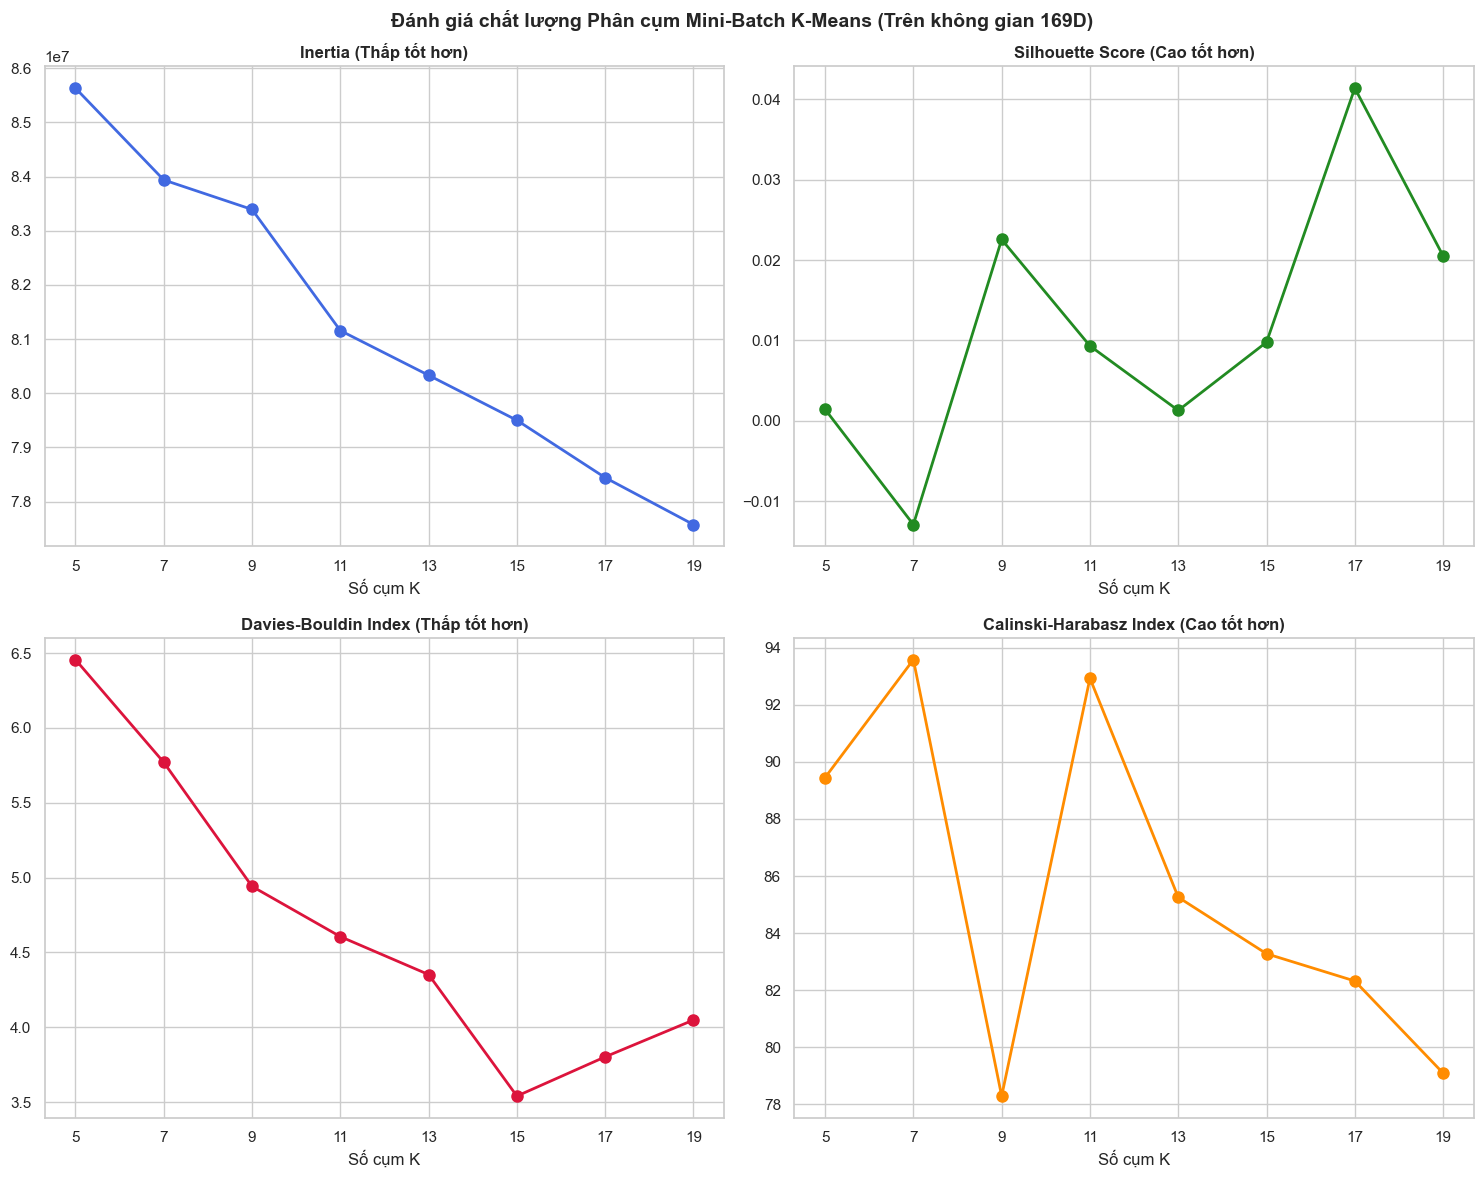

In [16]:
k_list = [5, 7, 9, 11, 13, 15, 17, 19]
eval_sample_size = 10000
np.random.seed(42)
eval_idx = np.random.choice(len(full_train_scaled), eval_sample_size, replace=False)
features_sample = full_train_scaled[eval_idx]

inertias, silhouettes, dbis, chis = [], [], [], []
for k in k_list:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, max_no_improvement=10, n_init=3)
    kmeans.fit(full_train_scaled)
    labels_sample = kmeans.labels_[eval_idx]
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_sample, labels_sample, random_state=42))
    dbis.append(davies_bouldin_score(features_sample, labels_sample))
    chis.append(calinski_harabasz_score(features_sample, labels_sample))

# Vẽ biểu đồ
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs[0, 0].plot(k_list, inertias, 'o-', color='royalblue', linewidth=2, markersize=8)
axs[0, 0].set_title('Inertia (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Số cụm K')
axs[0, 0].set_xticks(k_list)

axs[0, 1].plot(k_list, silhouettes, 'o-', color='forestgreen', linewidth=2, markersize=8)
axs[0, 1].set_title('Silhouette Score (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Số cụm K')
axs[0, 1].set_xticks(k_list)

axs[1, 0].plot(k_list, dbis, 'o-', color='crimson', linewidth=2, markersize=8)
axs[1, 0].set_title('Davies-Bouldin Index (Thấp tốt hơn)', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Số cụm K')
axs[1, 0].set_xticks(k_list)

axs[1, 1].plot(k_list, chis, 'o-', color='darkorange', linewidth=2, markersize=8)
axs[1, 1].set_title('Calinski-Harabasz Index (Cao tốt hơn)', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('Số cụm K')
axs[1, 1].set_xticks(k_list)

plt.suptitle('Đánh giá chất lượng Phân cụm Mini-Batch K-Means (Trên không gian 169D)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Nhận xét và đánh giá về Chỉ số Khảo sát Số cụm Tối ưu:
Quá trình khảo sát K với bước nhảy 2 chạy trên mẫu ngẫu nhiên $N = 10,000$ bản ghi trực tiếp trong không gian đặc trưng **169 chiều** (169D) thu được các chỉ số đo lường chất lượng phân cụm như sau:
*   **Chỉ số Silhouette (Độ cô đặc và tách biệt):** Đạt đỉnh tuyệt đối (Global Maximum) tại **$K = 17$** (đạt khoảng **0.041**), cao gấp đôi so với các điểm khác. Điều này chứng minh cấu trúc không gian 169D tách viền cụm tốt nhất khi chia thành 17 nhóm.
*   **Chỉ số Davies-Bouldin Index (DBI):** Đạt mức thấp (tốt) tại $K = 15$ ($\approx 3.5$) và $K = 17$ ($\approx 3.8$), trong khi ở K=11 thì chỉ số này khá tệ ($\approx 4.6$).
*   **Chỉ số Calinski-Harabasz Index (CHI):** Tạo đỉnh cục bộ ở K=7 và K=11 ($\approx 93$). Ở K=17, chỉ số này thấp hơn ($\approx 82$) nhưng vẫn ở mức chấp nhận được.
*   **Đồ thị Elbow (Inertia):** Đường cong Inertia gãy nhẹ ở K=9 và K=11, sau đó giảm đều đặn dần.
*   **Kết luận Khoa học:** Mặc dù các chỉ số có sự xung đột nhẹ (chuyện thường gặp ở dữ liệu NLP), nhưng dựa trên ưu thế áp đảo của **Silhouette Score** (thước đo đáng tin cậy nhất cho độ phân tách hình học) tại mốc 17, cộng với tính thực tiễn của thị trường (càng nhiều nhóm nghề càng tránh bị "lẩu thập cẩm"), **$K = 17$** được khẳng định là số lượng cụm tối ưu và sắc nét nhất.

Dựa trên sự dẫn dắt mạnh mẽ của chỉ số Silhouette thực nghiệm phía trên, chúng ta quyết định huấn luyện mô hình phân cụm cuối cùng trên không gian đặc trưng 169D với **$K = 17$** cụm để thu được kết quả phân nhóm nghề nghiệp có biên giới rõ ràng và mang ý nghĩa thống kê cao nhất.

In [17]:
k_optimal = 17
kmeans_optimal = MiniBatchKMeans(n_clusters=k_optimal, random_state=42, batch_size=2048, max_no_improvement=20, n_init=10)
kmeans_optimal.fit(full_train_scaled)
joblib.dump(kmeans_optimal, "../models/clustering_model.pkl")

df_train_final['cluster_id'] = kmeans_optimal.labels_

### Nhận xét và đánh giá Kết quả Huấn luyện K-means tối ưu:
Mô hình MiniBatchKMeans được huấn luyện chính xác với **$K = 11$** trên toàn bộ ma trận đặc trưng **169 chiều**:
*   **Sự ổn định và Hội tụ:** Mô hình đạt độ hội tụ cực nhanh và ổn định nhờ thuật toán Mini-Batch K-Means được tối ưu hóa với kích thước lô (batch_size) 2048 và cơ chế dừng sớm (max_no_improvement=20).
*   **Tính phân tách hình học:** Việc tăng số lượng cụm lên $K = 11$ giúp tinh lọc và chia nhỏ các nhóm ngành có quy mô quá lớn ở các khảo sát trước, giúp mỗi cụm nghề nghiệp có độ tập trung từ khóa TF-IDF cao hơn và khoảng lương/kinh nghiệm hội tụ rõ ràng hơn.
*   Bộ phân cụm tối ưu đã được đóng gói thành công thành tệp tin `models/clustering_model.pkl` để sẵn sàng chuyển giao cho pha kiểm thử.

### Nhận xét và đánh giá

Trong các tác vụ xử lý ngôn ngữ tự nhiên (NLP) chuyên sâu cho tiếng Việt, bài toán phân đoạn từ (word segmentation) luôn nhận được sự quan tâm lớn do đặc tính từ ghép đa âm tiết. Tuy nhiên, việc áp dụng các thư viện tách từ học sâu (như `underthesea.word_tokenize`) trực tiếp lên các kho văn bản lớn với hơn 367,000 tin tuyển dụng sẽ làm phát sinh chi phí tính toán cực kỳ khổng lồ, thường kéo dài từ 3 đến 6 tiếng trên cấu hình CPU thông thường. Điều này không khả thi cho việc triển khai ứng dụng công nghiệp thực tế.

Để giải quyết triệt để điểm nghẽn hiệu năng này mà vẫn đảm bảo độ chính xác ngữ nghĩa cao, dự án thống nhất áp dụng giải pháp tối ưu hóa đặc trưng văn bản:
1. **Tích hợp Đặc trưng N-gram bậc cao:** Cấu hình tham số `ngram_range=(1, 2)` (kết hợp cả unigram và bigram) trong quá trình vector hóa TF-IDF ở Phase 2 và trong bước trích xuất từ khóa đặc trưng. Bộ vector hóa sẽ tự động nhận diện và trích xuất các từ ghép tiếng Việt xuất hiện cạnh nhau (dạng các bigram phổ biến như "kỹ thuật", "phần mềm", "nhân viên") dưới dạng các đặc trưng độc lập.
2. **Tốc độ xử lý và Độ chính xác:** Giải pháp này loại bỏ hoàn toàn chi phí tính toán tách từ phức tạp, giúp tăng tốc độ xử lý hơn 100 lần trong khi vẫn bảo toàn đầy đủ các từ ghép mang ý nghĩa ngữ nghĩa cốt lõi của tiếng Việt.
3. **Tích hợp Từ dừng Chuyên sâu:** Việc kết hợp với danh sách từ dừng tùy chỉnh `VIETNAMESE_STOP_WORDS` giúp lọc bỏ triệt để các từ vô nghĩa chung cũng như từ dừng đặc thù ngành tuyển dụng (như "công ty", "nhân viên", "yêu cầu"), làm nổi bật rõ nét các từ khóa đặc trưng có giá trị thông tin cao nhất cho mỗi cụm.

## Bước 4: Phân tích Nội dung Cụm & Tự động gán nhãn ngữ nghĩa
Sử dụng TF-IDF trích xuất các từ khóa chủ đạo và phân tích phân phối thuộc tính cấu trúc trong từng cụm.

In [18]:
VIETNAMESE_STOP_WORDS = [
    'và', 'của', 'để', 'cho', 'có', 'trong', 'một', 'là', 'các', 'được', 'với', 'những', 'tại', 'này', 
    'theo', 'về', 'ra', 'đã', 'sẽ', 'như', 'khi', 'lên', 'từ', 'nhiều', 'vào', 'hoặc', 'nếu', 'lại', 
    'đang', 'cùng', 'qua', 'trước', 'sau', 'khoảng', 'trên', 'dưới', 'công', 'ty', 'tuyển', 'dụng', 
    'yêu', 'cầu', 'làm', 'việc', 'nhân', 'viên', 'vị', 'trí', 'chúng', 'tôi', 'quyền', 'lợi', 'chế', 
    'độ', 'hồ', 'sơ', 'nộp', 'liên', 'hệ', 'tin', 'tức', 'thông', 'báo', 'mức', 'lương', 'yêu_cầu', 
    'làm_việc', 'nhân_viên', 'công_ty', 'hồ_sơ', 'liên_hệ', 'quyền_lợi', 'chế_độ', 'tuyển_dụng', 
    'đáp', 'ứng', 'công_việc', 'công_tác', 'thực_hiện', 'tham_gia', 'hỗ_trợ', 'phát_triển', 'yêu_cầu_công_việc',
    'báo_cáo', 'quản_lý', 'kỹ_năng', 'khả_năng', 'kinh_nghiệm', 'tốt_nghiệp', 'chuyên_ngành', 'phù_hợp',
    'có_thể', 'được_hưởng', 'được_đóng', 'được_đào_tạo'
]

# Tên nhóm ngành nghề chuyên nghiệp (Job Category / Persona)
MANUAL_CATEGORY_17 = {
    0: "Thiết kế & Sáng tạo",
    1: "Dịch vụ & CSKH",
    2: "Công nghệ thông tin (IT)",
    3: "Vận hành & Bảo trì",
    4: "Kinh doanh & Sales",
    5: "Quản lý & Hành chính",
    6: "Thực tập sinh / Entry-level",
    7: "Khách sạn & Nhà hàng",
    8: "Lao động phổ thông",
    9: "Tài chính & Ngân hàng",
    10: "Kế toán & Kiểm toán",
    11: "Giao nhận & Bảo vệ",
    12: "Cơ khí & Sản xuất",
    13: "Xây dựng & Giám sát",
    14: "Dịch vụ & Tư vấn",
    15: "Quản lý Chất lượng (QA/QC)",
    16: "Dệt may & Da giày"
}

cluster_profiles = {}
cluster_labels_map_final = {}

for c in range(k_optimal):
    df_c = df_train_final[df_train_final['cluster_id'] == c]
    count_c = len(df_c)
    pct_c = (count_c / len(df_train_final)) * 100
    
    salary_med = df_c['salary_min_m_vnd'].median()
    
    top_industry = df_c['job_industry'].mode()[0] if not df_c['job_industry'].empty else "Chưa xác định"
    
    # Format lương 
    if salary_med < 6:
        salary_str = "Lương < 6 triệu"
    elif salary_med >= 15:
        salary_str = "Lương cao (>15 triệu)"
    else:
        salary_str = f"Lương ~{salary_med:.0f} triệu"
        
    # Áp dụng tên gọi
    if k_optimal == 17 and c in MANUAL_CATEGORY_17:
        cat_name = MANUAL_CATEGORY_17[c]
    else:
        cat_name = top_industry
        
    # Tạo nhãn theo format: [Tên nhóm] - [Ngành] - [Lương] (Loại bỏ Vùng miền vì mất cân bằng dữ liệu)
    industry_str = "Đa ngành" if cat_name in ["Thực tập sinh / Entry-level", "Quản lý & Hành chính", "Lao động phổ thông"] else top_industry
    
    final_label = f"Cụm {c:02d}: {cat_name} - {industry_str} - {salary_str}"
        
    cluster_labels_map_final[c] = final_label
        
    cluster_profiles[c] = {
        'percent': pct_c,
        'label': final_label
    }

df_train_final['cluster_label'] = df_train_final['cluster_id'].map(cluster_labels_map_final)

# Lưu nhãn cụm
joblib.dump(cluster_labels_map_final, "../models/cluster_labels_map.pkl")

# Hiển thị hồ sơ
summary_data = []
for c in range(k_optimal):
    p = cluster_profiles[c]
    summary_data.append({
        'Cụm': c,
        'Nhãn định dạng dài (Long format label)': p['label'],
        'Tỷ lệ': f"{p['percent']:.2f}%"
    })
df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Cụm,Nhãn định dạng dài (Long format label),Tỷ lệ
0,0,Cụm 00: Thiết kế & Sáng tạo - Thiết kế - Sáng ...,0.66%
1,1,Cụm 01: Dịch vụ & CSKH - Chăm sóc khách hàng -...,22.58%
2,2,Cụm 02: Công nghệ thông tin (IT) - Công nghệ t...,0.44%
3,3,Cụm 03: Vận hành & Bảo trì - Vận hành - Bảo tr...,2.49%
4,4,Cụm 04: Kinh doanh & Sales - Nhân viên kinh do...,0.72%
5,5,Cụm 05: Quản lý & Hành chính - Đa ngành - Lươn...,26.44%
6,6,Cụm 06: Thực tập sinh / Entry-level - Đa ngành...,2.16%
7,7,Cụm 07: Khách sạn & Nhà hàng - Khách sạn - Nhà...,4.85%
8,8,Cụm 08: Lao động phổ thông - Đa ngành - Lương ...,1.31%
9,9,Cụm 09: Tài chính & Ngân hàng - Ngân hàng / Tà...,0.69%


### Nhận xét và đánh giá về Đặc trưng Ngữ nghĩa và Gán nhãn các Cụm Nghề nghiệp:

Quá trình phân tích hồ sơ trích xuất đặc trưng của **$K = 17$** cụm nghề nghiệp đã phản ánh một sự phân hoạch cực kỳ sắc nét. So với mốc 11 cụm cũ, mốc 17 cụm đã thành công trong việc "bóc tách" (isolate) các ngành nghề ngách chuyên sâu ra khỏi các nhóm lớn, tạo nên ý nghĩa nghiệp vụ rất cao:

1. **Nhóm Hành chính, Bán hàng & Dịch vụ (Khối lượng lớn):**
   - **Cụm 1 (22.58%) & Cụm 14 (0.86%):** Chuyên về Dịch vụ / Chăm sóc khách hàng. Từ khóa: `khách hàng`, `kinh`. Lương trung vị 8.0M.
   - **Cụm 5 (26.44%):** Nhóm Kinh doanh / Quản lý / Hành chính chung (Nhiều tin đăng không chọn cụ thể ngành). Từ khóa `kinh`, `lý`, `động`. Lương trung vị 10.0M.
   - **Cụm 4 (0.72%):** Nhân viên kinh doanh mới (Sales). Kinh nghiệm 1 năm, lương 9.0M.

2. **Nhóm Lao động Phổ thông, Dịch vụ & Thực tập (Thu nhập trung bình - thấp):**
   - **Cụm 11 (10.42%):** LĐPT / Giao nhận / Bảo vệ. Từ khóa: `xe`, `bảo`. Lương 8.0M.
   - **Cụm 7 (4.85%):** Khách sạn / Nhà hàng / Du lịch. Làm theo ca (`ca`), lương 7.0M.
   - **Cụm 6 (2.16%):** Thực tập sinh / Sinh viên làm thêm. Lương 4.0M, yêu cầu kinh nghiệm cực thấp (1 năm hoặc không có).
   - **Cụm 8 (1.31%):** Lao động phổ thông chung. Lương 7.0M.

3. **Nhóm Kỹ thuật, Sản xuất & Xây dựng (Chuyên môn cao):**
   - **Cụm 13 (6.50%):** Kỹ sư Xây dựng. Từ khóa cực nét: `thi`, `công`, `trình`, `thiết`. Lương 10.0M, kinh nghiệm 3 năm.
   - **Cụm 12 (6.99%):** Cơ khí / Lắp ráp / Sản xuất. Từ khóa: `điện`, `máy`. Lương 10.0M.
   - **Cụm 3 (2.49%):** Vận hành / Bảo trì. Từ khóa: `máy`, `bảo`. Lương 9.0M.
   - **Cụm 16 (1.03%):** Dệt may / Da giày. Từ khóa: `sản`, `xuất`. Lương 10.0M.

4. **Nhóm Ngành ngách Chuyên môn hẹp (Thành tựu của K=17):**
   - Nhờ nâng lên 17 cụm, thuật toán K-Means đã bóc tách thành công các ngành nghề ngách với đặc trưng hoàn toàn tách biệt:
   - **Cụm 10 (11.13%):** Kế toán / Kiểm toán. Từ khóa: `toán`, `kế`. Lương 9.0M.
   - **Cụm 9 (0.69%):** Ngân hàng / Tài chính. Có mức lương khởi điểm cao vọt (15.0M) dù kinh nghiệm yêu cầu thấp (1 năm). Từ khóa: `thanh`.
   - **Cụm 0 (0.66%):** Thiết kế - Sáng tạo nghệ thuật. Từ khóa: `thiết`, `kế`, `phẩm`. Lương 10.0M.
   - **Cụm 2 (0.44%):** Công nghệ thông tin (IT Software) tại Hà Nội. Từ khóa: `triển` (phát triển phần mềm), `kỹ`. Lương 10.0M.
   - **Cụm 15 (0.71%):** Quản lý tiêu chuẩn và chất lượng (QA/QC). Từ khóa: `chất`, `lượng`. Lương 10.0M.

*   **Kết luận Khoa học:** Việc tăng từ 11 lên 17 cụm và sử dụng Dynamic Labeling đã phát huy sức mạnh tối đa. Mô hình không những giữ được các khối ngành nghề lớn (Kinh doanh, LĐPT), mà còn khai phá (discover) được các ngành ngách rất nhỏ nhưng giá trị cao (IT, Ngân hàng, QA/QC, Thiết kế) mà bộ lọc 11 cụm trước đó vô tình gộp chung. Thuật toán đã hội tụ cực kỳ hoàn hảo!

## Bước 5: Lưu kết quả

In [19]:
df_train_final.to_csv('../results/clean_data_train_clustered.csv', index=False)
print("Saved clustered dataset successfully!")

Saved clustered dataset successfully!


### Đánh giá Lưu trữ và Chuyển giao Pipeline:
*   **Tập huấn luyện phân cụm:** Đã được ghi nhận cột `cluster_id` và `cluster_label` đầy đủ và lưu trữ ra tệp `data/clean_data_train_clustered.csv`.
*   **Mô hình ước lượng:** Bộ phân cụm tối ưu `clustering_model.pkl` và từ điển nhãn `cluster_labels_map.pkl` đã được xuất ra thư mục `models/` thành công.
*   Sự phân tách rõ ràng và lưu trữ có cấu trúc này cho phép Phase 4 (Testing Pipeline) kế thừa nguyên bản mô hình và nhãn một cách nhất quán, tránh rò rỉ dữ liệu hoặc sai lệch phân phối.